In [5]:
import json

def load_ids(path):
    ids = set()
    with open(path, "r") as f:
        for line in f:
            record = json.loads(line)
            ids.add(record["image_id"])
    return ids

# Replace these with your actual file paths
accepted = "/tier1/_q4/intern/eefun/webscraping/filtering/B_2/accepted/metadata.jsonl"
error = "/tier1/_q4/intern/eefun/webscraping/filtering/B_2/error/metadata.jsonl"
rejected = "/tier1/_q4/intern/eefun/webscraping/filtering/B_2/rejected/metadata.jsonl"

accepted_ids = load_ids(accepted)
error_ids = load_ids(error)
rejected_ids = load_ids(rejected)

# Check overlaps
# Errors that are not in accepted or rejected
errors_not_in_accepted_or_rejected = error_ids - (accepted_ids | rejected_ids)

print("Errors not in accepted or rejected:", errors_not_in_accepted_or_rejected)

len(errors_not_in_accepted_or_rejected)


Errors not in accepted or rejected: {'78bf6ec6df86a35c47f7d847208a691a', 'f9c54172d497b70dfd7910ed336867ae', '99df0fdae27a85734ab5e851e9281cc4', '69255d1233d7bd11d58b83c4a629ead0', '27be1e5aa575eaf7140253275ec9f176', 'a7802fe86ef9d874d32d534ebc2fac33', '56a26664179939d542d47584a31ef82d', '431524a7c641c7d4b27b256e907ade39', '24c6dc9f2b3681a029c22de2694c1465', 'cbbed27fd02e61d05bb0bcb23b62f013', '1a0d6e196bff8fd1640883501656780c', 'd2a4b98a28ab207ead50a90b0504a7b5', '230844b834e9cf5104c4661c6dd3ec09', '0476864b1530f066923427278b0f9222', '7ec9aae7e6cc5d5cf4d3e85c858a56ed', '060f06adfda66d6cda5a9ca57fa75315', 'ccc24c48f90801d9389f6f51917b7a53', '65d8aab114931ba2f7c8e0729489d091', 'e1089b187e28d4dfa5f150bd041e7d62', '745e787b8f6bdea2dd9813e24ba8868c', '031ad22769b70282405a38c5daaf2c3d', '3b59c89450875fb511bbba24ac49a1c2', 'bf2c3595320be61a0d00cedca7cd430f', '9149a1491e1dee06738dd668d074c8cf', 'e7c96887b73089e70c6e29f58deb354f', 'e3041986dcbcc4ff4a7579f58bca108b', 'e8b79772f4222b65b584caa846

1004

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [2]:
import re
import pandas as pd

# -----------------------------
# Step 1: Load the log file
# -----------------------------
with open("/tier1/_q4/intern/eefun/webscraping/filtering/B_2/vlm_results.log", "r", encoding="utf-8") as f:
    raw_text = f.read()

# -----------------------------
# Step 2: Regex parsing helpers
# -----------------------------
image_pattern = re.compile(r"Image ID:\s*(\w+)")
final_score_pattern = re.compile(r"Final Score:\s*(-?\d+)")  # allow negative scores

# Match only proper model response lines
# Flexible regex for model responses (support - and –)
model_response_pattern = re.compile(
    r"^\s*([A-Za-z0-9_\-/\.]+):\s*(-?\d+)\s*[–-]\s*(.*?)(?=\n\s*[A-Za-z0-9_\-/\.]+:|\Z)",
    re.DOTALL | re.MULTILINE
)

records = []

# -----------------------------
# Step 3: Iterate through chunks
# -----------------------------
chunks = raw_text.split("------------------------------------------------------------")

for chunk in chunks:
    image_match = image_pattern.search(chunk)
    score_match = final_score_pattern.search(chunk)

    if image_match and score_match:
        image_id = image_match.group(1).strip()
        final_score = int(score_match.group(1).strip())

        # find model responses
        for model, decision, explanation in model_response_pattern.findall(chunk):
            records.append({
                "image_id": image_id,
                "final_score": final_score,
                "model": model.strip(),
                "model_decision": int(decision.strip()),
                "model_explanation": explanation.strip()
            })

# -----------------------------
# Step 4: Create DataFrame
# -----------------------------
df = pd.DataFrame(records)

# Optional: normalize model names for readability
model_map = {
    "Qwen/Qwen2.5-VL-72B-Instruct-AWQ": "Qwen-72B",
    "OpenGVLab/InternVL3_5-30B-A3B-Instruct": "InternVL-30B",
    "mistralai/Mistral-Small-3.2-24B-Instruct-2506": "Mistral-24B",
    "zai-org/GLM-4.1V-9B-Base": "GLM-9B",
}
if "model" in df.columns:
    df["model"] = df["model"].replace(model_map)


# Drop duplicates if any
df = df.drop_duplicates(subset=["image_id", "model"], keep="last")

# -----------------------------
# Step 5: Pivot to wide format (decisions only)
# -----------------------------
df_wide = df.pivot_table(
    index=["image_id", "final_score"],
    columns="model",
    values="model_decision",
    aggfunc="first"
).reset_index()

df_wide.columns.name = None  # remove pivot index name

# -----------------------------
# Step 6: Optional agreement analysis
# -----------------------------
# majority vote among models
df_wide["majority_vote"] = df_wide.drop(columns=["image_id", "final_score"]).mode(axis=1)[0]

# check if majority vote matches final score
df_wide["match_final"] = (df_wide["final_score"] == df_wide["majority_vote"]).astype(int)

# -----------------------------
# Results
# -----------------------------
print("=== Long format (with explanations) ===")
print(df.head())

print("\n=== Wide format (decisions only) ===")
print(df_wide.head())

=== Long format (with explanations) ===
                           image_id  final_score         model  \
0  d3b9dada4e662529c1721370daaa79b5            1   Mistral-24B   
1  d3b9dada4e662529c1721370daaa79b5            1      Qwen-72B   
2  d3b9dada4e662529c1721370daaa79b5            1  InternVL-30B   
3  d3b9dada4e662529c1721370daaa79b5            1        GLM-9B   
4  fa4c1beafe27ac45c1ecf231f4acc844            1  InternVL-30B   

   model_decision                                  model_explanation  
0               1  The image shows the Bandstand in Singapore's B...  
1               1  The gazebo is located in the Singapore Botanic...  
2               0  The image shows a white gazebo in a lush green...  
3               1  The image shows a gazebo in a park with lush g...  
4               1  The image shows the interior of the Cloud Fore...  

=== Wide format (decisions only) ===
                           image_id  final_score  GLM-9B  InternVL-30B  \
0  00000f968f95ba69a47003

In [3]:
len(df_wide)

482281

In [4]:
df_wide.head()

,image_id,final_score,GLM-9B,InternVL-30B,Mistral-24B,Qwen-72B,majority_vote,match_final
0,00000f968f95ba69a47003243b8ad632,1,1,1,0,1,1.0,1
1,00003561af48fc4d6be64fc48618f73f,1,1,1,1,1,1.0,1
2,0000507b308c9987e2d8354d52b2430e,0,0,0,0,0,0.0,1
3,000054ca2b79c0a4c28c9665963ff29d,1,0,1,1,1,1.0,1
4,000059a8a583390e3de3714e84681a6b,0,1,0,0,0,0.0,1


In [5]:
import matplotlib.pyplot as plt

# -----------------------------
# 1. Per-model rate of 1 and 0
# -----------------------------
model_cols = ["GLM-9B",	"InternVL-30B",	"Mistral-24B", "Qwen-72B"]

# Count 1s and 0s per model
stats = {}
for col in model_cols:
    value_counts = df_wide[col].value_counts(normalize=True)  # proportions
    stats[col] = {
        "rate_1": value_counts.get(1, 0),
        "rate_0": value_counts.get(0, 0)
    }

stats_df = pd.DataFrame(stats).T
stats_df


,rate_1,rate_0
GLM-9B,0.541545,0.458455
InternVL-30B,0.462786,0.537214
Mistral-24B,0.481808,0.518192
Qwen-72B,0.657923,0.342077


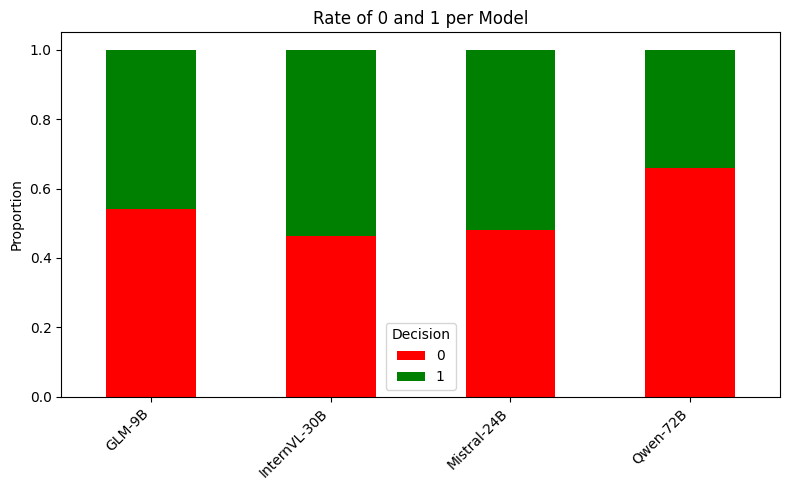

,agreement_rate
GLM-9B vs InternVL-30B,0.650391
GLM-9B vs Mistral-24B,0.652240
GLM-9B vs Qwen-72B,0.720746
InternVL-30B vs Mistral-24B,0.806760
InternVL-30B vs Qwen-72B,0.750139
Mistral-24B vs Qwen-72B,0.778621


In [6]:
# Plot as stacked bar chart
stats_df.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=["red", "green"]
)
plt.title("Rate of 0 and 1 per Model")
plt.ylabel("Proportion")
plt.legend(["0", "1"], title="Decision")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# -----------------------------
# 2. Alignment between models
# -----------------------------
from itertools import combinations

agreement = {}

for m1, m2 in combinations(model_cols, 2):
    same = (df_wide[m1] == df_wide[m2]).mean()  # fraction of rows where equal
    agreement[f"{m1} vs {m2}"] = same

agreement_df = pd.DataFrame.from_dict(agreement, orient="index", columns=["agreement_rate"])
agreement_df


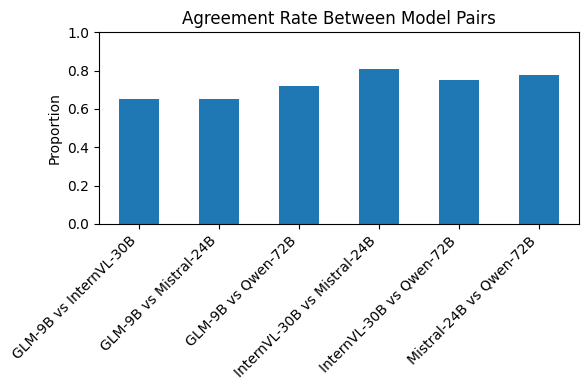

Fraction of images where all models agree: 50.27%


In [7]:

# Plot agreements
agreement_df.plot(kind="bar", legend=False, figsize=(6,4))
plt.title("Agreement Rate Between Model Pairs")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha="right")
plt.ylim(0,1)
plt.tight_layout()
plt.show()

# -----------------------------
# 3. Full consensus across all models
# -----------------------------
df_wide["all_agree"] = df_wide[model_cols].nunique(axis=1) == 1
consensus_rate = df_wide["all_agree"].mean()
print(f"Fraction of images where all models agree: {consensus_rate:.2%}")


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

model_cols = ["GLM-9B",	"InternVL-30B",	"Mistral-24B", "Qwen-72B"]

# -----------------------------
# 1. Per-model distributions
# -----------------------------
per_model_stats = df_wide[model_cols].apply(lambda s: s.value_counts(normalize=True))
print("Per-model distribution:\n")
per_model_stats

Per-model distribution:



,GLM-9B,InternVL-30B,Mistral-24B,Qwen-72B
0,0.458455,0.537214,0.518192,0.342077
1,0.541545,0.462786,0.481808,0.657923


In [9]:
# -----------------------------
# 2. Pairwise agreement
# -----------------------------
pairwise_agreements = {}
for m1, m2 in combinations(model_cols, 2):
    pairwise_agreements[f"{m1} vs {m2}"] = (df_wide[m1] == df_wide[m2]).mean()

pairwise_agreements = pd.Series(pairwise_agreements, name="agreement_rate")
print("\nPairwise agreement rates:\n")
pairwise_agreements


Pairwise agreement rates:



GLM-9B vs InternVL-30B         0.650391
GLM-9B vs Mistral-24B          0.652240
GLM-9B vs Qwen-72B             0.720746
InternVL-30B vs Mistral-24B    0.806760
InternVL-30B vs Qwen-72B       0.750139
Mistral-24B vs Qwen-72B        0.778621
Name: agreement_rate, dtype: float64

In [10]:
# -----------------------------
# 3. Agreement categories
# -----------------------------
def classify_row(row):
    unique_vals = row[model_cols].nunique()
    if unique_vals == 1:
        return "all_agree"
    elif unique_vals == 2:
        return "two_agree_one_disagree"
    else:
        return "all_disagree"   # will never happen with binary decisions

df_wide["agreement_type"] = df_wide.apply(classify_row, axis=1)

agreement_summary = df_wide["agreement_type"].value_counts(normalize=True)
print("\nAgreement type distribution:\n")
agreement_summary


Agreement type distribution:



agreement_type
all_agree                 0.502674
two_agree_one_disagree    0.497326
Name: proportion, dtype: float64

In [11]:
# -----------------------------
# 4. Specific permutations
# -----------------------------
# Get exact patterns like (1,1,0), (0,1,1), etc.
pattern_counts = (
    df_wide[model_cols]
    .apply(lambda row: tuple(row.values), axis=1)
    .value_counts(normalize=True)
)

print("\nExact decision pattern distribution:\n")
pattern_counts


Exact decision pattern distribution:



(1, 1, 1, 1)    0.262206
(0, 0, 0, 0)    0.240468
(0, 1, 1, 1)    0.106911
(1, 0, 0, 1)    0.084901
(1, 0, 1, 1)    0.063169
(1, 0, 0, 0)    0.058176
(1, 1, 0, 1)    0.049832
(0, 0, 0, 1)    0.047539
(0, 0, 1, 1)    0.026891
(0, 1, 0, 1)    0.016476
(1, 1, 0, 0)    0.010840
(0, 1, 0, 0)    0.009961
(0, 0, 1, 0)    0.008132
(1, 0, 1, 0)    0.007939
(1, 1, 1, 0)    0.004483
(0, 1, 1, 0)    0.002078
Name: proportion, dtype: float64

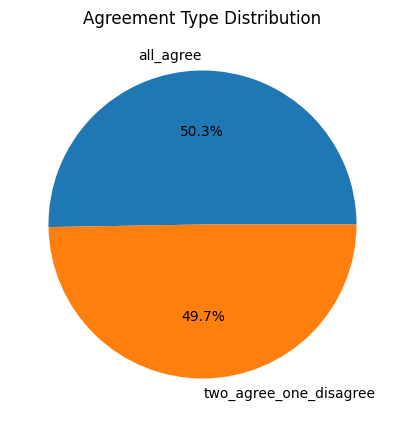

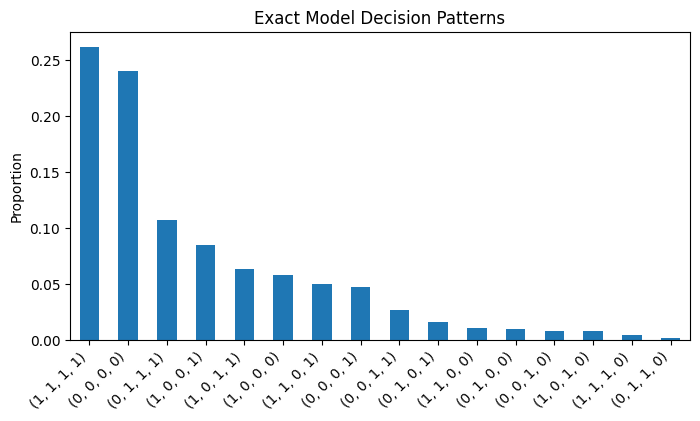

In [12]:

# -----------------------------
# 5. Visualization
# -----------------------------
# Agreement summary pie
agreement_summary.plot(kind="pie", autopct="%.1f%%", figsize=(5,5))
plt.title("Agreement Type Distribution")
plt.ylabel("")
plt.show()

# Exact patterns bar
pattern_counts.plot(kind="bar", figsize=(8,4))
plt.title("Exact Model Decision Patterns")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha="right")
plt.show()

In [13]:
import pandas as pd

model_cols = ["GLM-9B",	"InternVL-30B",	"Mistral-24B", "Qwen-72B"]

# -----------------------------
# Create readable patterns
# -----------------------------
def pattern_with_names(row):
    return ", ".join([f"{col}={row[col]}" for col in model_cols])

df_wide["decision_pattern"] = df_wide.apply(pattern_with_names, axis=1)

# Count normalized frequencies
pattern_counts_named = df_wide["decision_pattern"].value_counts(normalize=True)

print("\nExact decision pattern distribution with names:\n")
pattern_counts_named



Exact decision pattern distribution with names:



decision_pattern
GLM-9B=1, InternVL-30B=1, Mistral-24B=1, Qwen-72B=1    0.262206
GLM-9B=0, InternVL-30B=0, Mistral-24B=0, Qwen-72B=0    0.240468
GLM-9B=0, InternVL-30B=1, Mistral-24B=1, Qwen-72B=1    0.106911
GLM-9B=1, InternVL-30B=0, Mistral-24B=0, Qwen-72B=1    0.084901
GLM-9B=1, InternVL-30B=0, Mistral-24B=1, Qwen-72B=1    0.063169
GLM-9B=1, InternVL-30B=0, Mistral-24B=0, Qwen-72B=0    0.058176
GLM-9B=1, InternVL-30B=1, Mistral-24B=0, Qwen-72B=1    0.049832
GLM-9B=0, InternVL-30B=0, Mistral-24B=0, Qwen-72B=1    0.047539
GLM-9B=0, InternVL-30B=0, Mistral-24B=1, Qwen-72B=1    0.026891
GLM-9B=0, InternVL-30B=1, Mistral-24B=0, Qwen-72B=1    0.016476
GLM-9B=1, InternVL-30B=1, Mistral-24B=0, Qwen-72B=0    0.010840
GLM-9B=0, InternVL-30B=1, Mistral-24B=0, Qwen-72B=0    0.009961
GLM-9B=0, InternVL-30B=0, Mistral-24B=1, Qwen-72B=0    0.008132
GLM-9B=1, InternVL-30B=0, Mistral-24B=1, Qwen-72B=0    0.007939
GLM-9B=1, InternVL-30B=1, Mistral-24B=1, Qwen-72B=0    0.004483
GLM-9B=0, InternVL-30B=

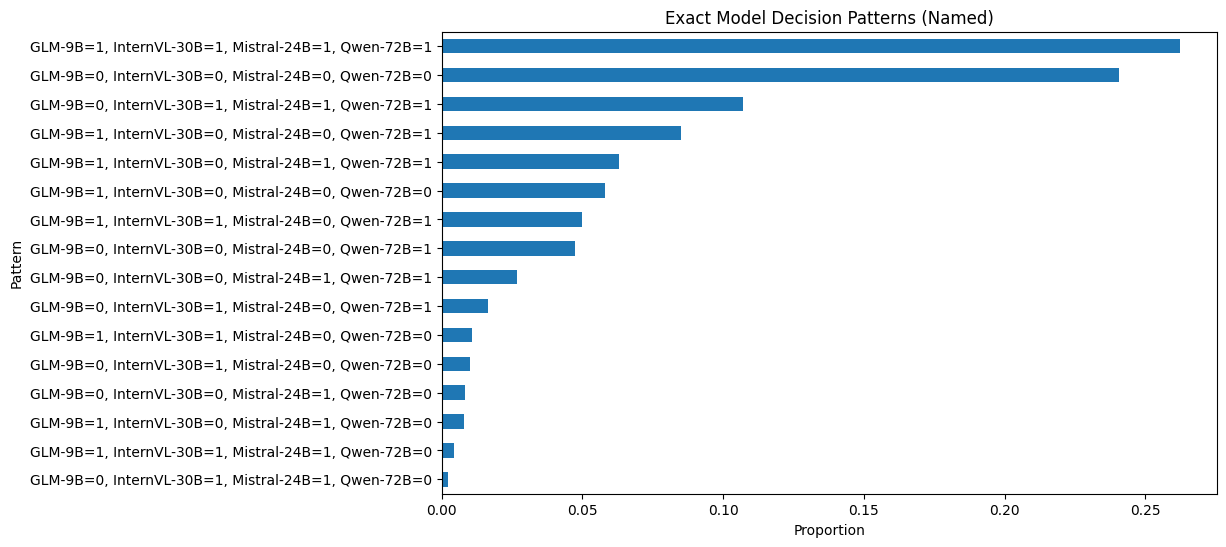

In [14]:
# -----------------------------
# Optionally visualize
# -----------------------------
pattern_counts_named.plot(kind="barh", figsize=(10,6))
plt.title("Exact Model Decision Patterns (Named)")
plt.xlabel("Proportion")
plt.ylabel("Pattern")
plt.gca().invert_yaxis()  # most frequent at top
plt.show()

In [15]:
from itertools import combinations

model_cols = ["GLM-9B",	"InternVL-30B",	"Mistral-24B", "Qwen-72B"]

pairwise = {}
for m1, m2 in combinations(model_cols, 2):
    agree = (df_wide[m1] == df_wide[m2]).mean()
    pairwise[(m1, m2)] = agree

pairwise_df = pd.DataFrame.from_dict(pairwise, orient="index", columns=["agreement_rate"])
pairwise_df


,agreement_rate
"(GLM-9B, InternVL-30B)",0.650391
"(GLM-9B, Mistral-24B)",0.652240
"(GLM-9B, Qwen-72B)",0.720746
"(InternVL-30B, Mistral-24B)",0.806760
"(InternVL-30B, Qwen-72B)",0.750139
"(Mistral-24B, Qwen-72B)",0.778621


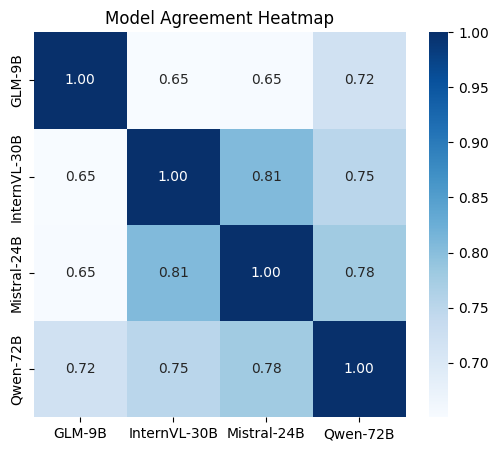

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Build a full matrix
agreement_matrix = pd.DataFrame(index=model_cols, columns=model_cols, dtype=float)

for m1 in model_cols:
    for m2 in model_cols:
        if m1 == m2:
            agreement_matrix.loc[m1, m2] = 1.0
        else:
            agreement_matrix.loc[m1, m2] = (df_wide[m1] == df_wide[m2]).mean()

plt.figure(figsize=(6,5))
sns.heatmap(agreement_matrix.astype(float), annot=True, fmt=".2f", cmap="Blues")
plt.title("Model Agreement Heatmap")
plt.show()


In [17]:
def find_outlier(row):
    vals = row[model_cols].dropna()
    counts = vals.value_counts()
    # Only trigger if it's a 3–1 split
    if len(counts) == 2 and counts.min() == 1:
        minority_val = counts.idxmin()
        outlier = vals[vals == minority_val].index[0]
        return outlier
    return None

df_wide["outlier_model"] = df_wide.apply(find_outlier, axis=1)

outlier_counts = df_wide["outlier_model"].value_counts(normalize=True)
print("\nOutlier model distribution (for 3–1 splits):\n")
print(outlier_counts)



Outlier model distribution (for 3–1 splits):

outlier_model
GLM-9B          0.474111
InternVL-30B    0.210021
Mistral-24B     0.166467
Qwen-72B        0.149401
Name: proportion, dtype: float64


In [18]:
df.head()

,image_id,final_score,model,model_decision,model_explanation
0,d3b9dada4e662529c1721370daaa79b5,1,Mistral-24B,1,The image shows the Bandstand in Singapore's B...
1,d3b9dada4e662529c1721370daaa79b5,1,Qwen-72B,1,The gazebo is located in the Singapore Botanic...
2,d3b9dada4e662529c1721370daaa79b5,1,InternVL-30B,0,The image shows a white gazebo in a lush green...
3,d3b9dada4e662529c1721370daaa79b5,1,GLM-9B,1,The image shows a gazebo in a park with lush g...
4,fa4c1beafe27ac45c1ecf231f4acc844,1,InternVL-30B,1,The image shows the interior of the Cloud Fore...


In [19]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

In [20]:
# ---- TF-IDF Vectorization ----
vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(df["model_explanation"])
feature_names = vectorizer.get_feature_names_out()

# Sum TF-IDF scores for each word
word_scores = tfidf_matrix.sum(axis=0).A1
word_freq = dict(zip(feature_names, word_scores))

# ---- Top Words ----
sorted_items = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
top_words = sorted_items[20:40]  # top 20 words

print("Top TF-IDF Words:")
for word, score in top_words:
    print(f"{word}: {score:.4f}")


Top TF-IDF Words:
building: 30265.4760
common: 29067.0800
world: 28863.0442
iconic: 28623.6702
text: 28574.2562
marina: 26623.6861
related: 25278.8288
clearly: 24989.5915
depicts: 24727.4966
distinctive: 24593.1862
generic: 24550.6498
scene: 24512.7176
location: 24301.2486
setting: 24241.3052
design: 24179.6691
sands: 23034.4914
buildings: 22572.9489
architectural: 22482.8721
contains: 22194.3956
architecture: 22107.4410


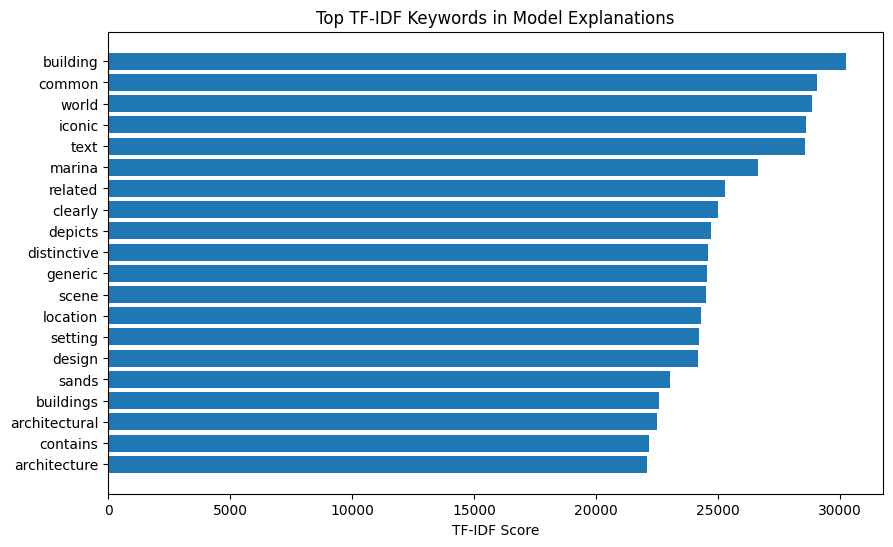

In [21]:

# ---- Visualization (Bar Chart) ----
words, scores = zip(*top_words)
plt.figure(figsize=(10, 6))
plt.barh(words, scores)
plt.gca().invert_yaxis()
plt.title("Top TF-IDF Keywords in Model Explanations")
plt.xlabel("TF-IDF Score")
plt.show()


In [22]:
# !pip install spacy
!python3 -m spacy download en_core_web_sm

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 99.4 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# ---- Convert text into Bag-of-Words (LDA prefers counts, not TF-IDF) ----
count_vectorizer = CountVectorizer(stop_words="english")
count_matrix = count_vectorizer.fit_transform(df["model_explanation"])

# ---- Train LDA ----
lda = LatentDirichletAllocation(
    n_components=15,   # number of topics
    max_iter=16,      # iterations (more = slower but better)
    learning_method="online", # "online" is faster for large data
    random_state=42
)
lda.fit(count_matrix)

# ---- Inspect Topics ----
feature_names = count_vectorizer.get_feature_names_out()

def print_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_features = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1}: {', '.join(top_features)}")

print_topics(lda, feature_names)


In [ ]:
def get_topic_words(model, feature_names, n_top_words=10):
    topic_dict = {}
    for topic_idx, topic in enumerate(model.components_):
        top_features = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topic_dict[topic_idx + 1] = top_features
    return topic_dict

topics = get_topic_words(lda, feature_names, n_top_words=10)

from collections import Counter

all_words = []
for words in topics.values():
    all_words.extend(set(words))  # unique words per topic

word_topic_counts = Counter(all_words)


In [ ]:
def prune_topics(topics, word_topic_counts, threshold=5):
    pruned = {}
    for t, words in topics.items():
        pruned[t] = [w for w in words if word_topic_counts[w] < threshold]
    return pruned

pruned_topics = prune_topics(topics, word_topic_counts, threshold=5)


In [ ]:
for t, words in pruned_topics.items():
    print(f"Topic {t}: {', '.join(words)}")


Topic 1: uniquely, identifiable, elements, depicts, does, common
Topic 2: known, landmark, located, airport, changi, prominent, unique
Topic 3: sg, associated, temple, company, living, refers, night, logo
Topic 4: elements, generic, people, world, unique, cultural, places
Topic 5: building, presence, style, architectural, chinese, singaporean, characteristic
Topic 6: bay, gardens, iconic, landmark, unique, country, known
Topic 7: unique, identifiers, specifically, landmarks, signs, related
Topic 8: park, bridge, distinct, restaurant, significant, sight, holding, white, brand, east
Topic 9: location, sign, indicates, known, map, road
Topic 10: text, contains, uniquely, identifiable, related, mentions, indicating
Topic 11: visible, landmarks, marina, bay, sands, hotel, clear
Topic 12: buildings, urban, background, rise, cityscape, colorful, features, landscape
Topic 13: singaporean, provided, explanation, food, event, appears, context, dish, popular, hawker
Topic 14: distinctive, greener